# DHT22 sensor timelines

Green **line charts** for DHT22 air temperature and humidity (reference style).

In [3]:
%matplotlib inline

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

FIG_PATH = Path('figures')
FIG_PATH.mkdir(exist_ok=True)

LINE_COLOR = '#27ae60'
BORDER_COLOR = '#27ae60'


def load_dht22_time_series(path: Path, time_col: str, value_col: str) -> pd.DataFrame:
    df = pd.read_excel(path)
    out = pd.DataFrame({
        'datetime': pd.to_datetime(df[time_col], utc=True).dt.tz_convert(None),
        'value': pd.to_numeric(df[value_col], errors='coerce'),
    }).dropna().sort_values('datetime').reset_index(drop=True)
    return out


def plot_dht22_line(
    df: pd.DataFrame,
    *,
    title: str,
    y_label: str,
    ylim: tuple[float, float],
    y_ticks: range,
    outfile: Path,
    date_format: str = '%d/%m/%Y %H:%M:%S',
    x_rotation: int = 90,
) -> None:
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(df['datetime'], df['value'], color=LINE_COLOR, linewidth=1.2)

    ax.set_title(title, fontsize=14, fontweight='bold', color='#333333')
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_xlabel('Date & Time', fontsize=11)

    ax.set_ylim(*ylim)
    ax.set_yticks(list(y_ticks))
    ax.yaxis.grid(True, linestyle='-', linewidth=0.5, color='#cccccc', alpha=0.8)
    ax.xaxis.grid(False)

    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=12))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
    plt.setp(ax.get_xticklabels(), rotation=x_rotation, ha='center' if x_rotation == 90 else 'right')

    ax.set_xlim(df['datetime'].min(), df['datetime'].max())
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER_COLOR)
        spine.set_linewidth(1.2)

    fig.patch.set_edgecolor(BORDER_COLOR)
    fig.patch.set_linewidth(1.5)

    fig.tight_layout()
    fig.savefig(outfile, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', outfile.resolve())

Temperature | rows: 15,003
  Range: 2025-06-20 15:26:50.910000 → 2025-09-24 10:41:57.964000
  Values: 25.3 – 47.7 °C


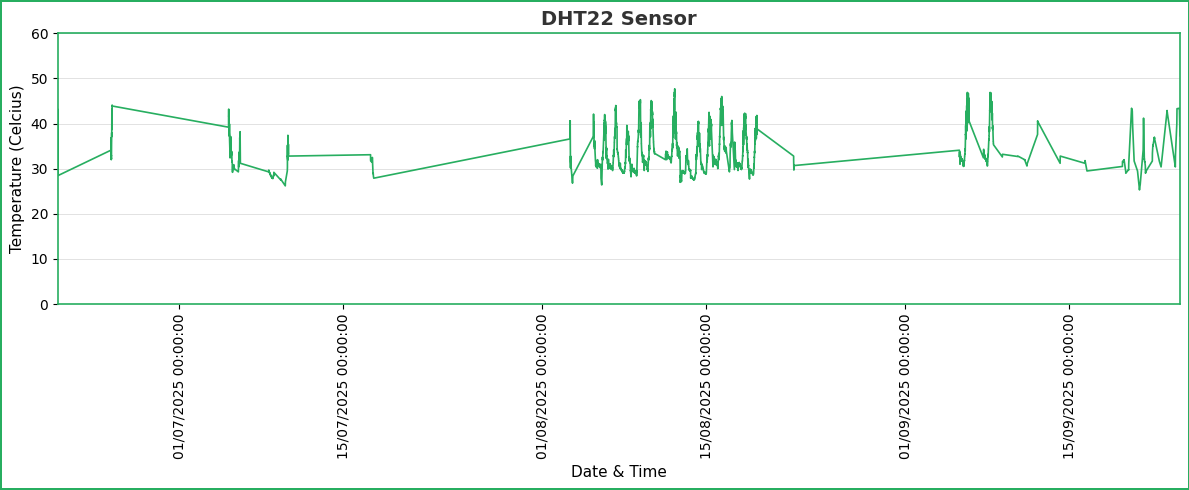

Saved: D:\StartUps\BitnBolt\hydroponics ML\new start 2\figures\dht22_sensor_temperature.png


In [4]:
TEMP_PATH = Path('data') / 'Air Temp Data (DHT22).xlsx'

df_temp = load_dht22_time_series(TEMP_PATH, 'createdAt', 'dht22Temp')
print(f'Temperature | rows: {len(df_temp):,}')
print(f'  Range: {df_temp["datetime"].min()} → {df_temp["datetime"].max()}')
print(f'  Values: {df_temp["value"].min():.1f} – {df_temp["value"].max():.1f} °C')

plot_dht22_line(
    df_temp,
    title='DHT22 Sensor',
    y_label='Temperature (Celcius)',
    ylim=(0, 60),
    y_ticks=range(0, 61, 10),
    outfile=FIG_PATH / 'dht22_sensor_temperature.png',
)

Humidity | rows: 15,003
  Range: 2025-06-20 15:26:50.910000 → 2025-09-24 10:41:57.964000
  Values: 41.8 – 100.0 %


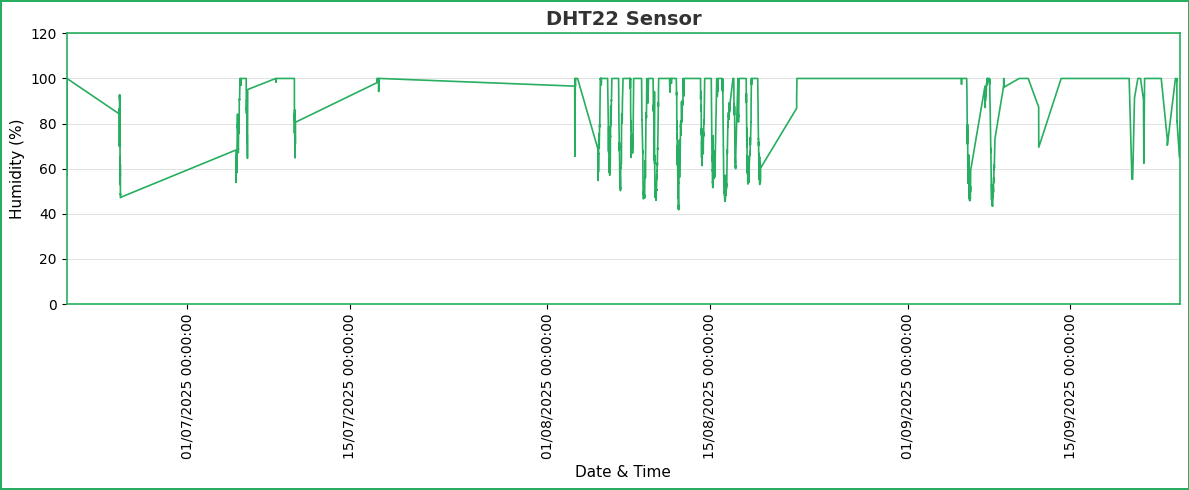

Saved: D:\StartUps\BitnBolt\hydroponics ML\new start 2\figures\dht22_sensor_humidity.png


In [5]:
MOISTURE_PATH = Path('data') / 'Air Moisture Data (DHT22).xlsx'

df_moisture = load_dht22_time_series(MOISTURE_PATH, 'Time', 'Moisture %')
print(f'Humidity | rows: {len(df_moisture):,}')
print(f'  Range: {df_moisture["datetime"].min()} → {df_moisture["datetime"].max()}')
print(f'  Values: {df_moisture["value"].min():.1f} – {df_moisture["value"].max():.1f} %')

plot_dht22_line(
    df_moisture,
    title='DHT22 Sensor',
    y_label='Humidity (%)',
    ylim=(0, 120),
    y_ticks=range(0, 121, 20),
    outfile=FIG_PATH / 'dht22_sensor_humidity.png',
)